In [1]:
import numpy as np
from scipy.optimize import minimize
import pandas as pd
import GPy
from scipy.special import expit
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.spatial import distance
import statsmodels.api as sm
import warnings
import numpy as np
from scipy.optimize import differential_evolution
from scipy.stats import rankdata
from sklearn.cross_decomposition import CCA
import math
import copy
from math import log
from collections import Counter
import pickle
from sklearn.linear_model import Lasso
warnings.filterwarnings("ignore")

In [2]:
# Read beta back from the file
beta_star = np.load('beta_star.npy')
print("beta_star:", beta_star)
n_features = len(beta_star)

np.sum(beta_star[beta_star > 0])

beta_star: [ 0.          0.          0.          0.          0.          0.
  0.          6.88077495  0.          0.          0.          0.
  0.         -2.78051968  0.          0.          0.          0.
  0.          0.          0.          7.43875894  0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          1.79766895  0.
  0.          0.          0.          0.          0.          0.
  0.          0.          2.05011646  0.          0.          0.
  0.          0.        ]


18.167319306406313

In [3]:
from sklearn.linear_model import Lasso

def lasso_stochastic_bandit(phi, T, C_max_wave, L, error_std, Y_t, X_t, beta_star):
    """
    Implements the preconditioning LASSO bandit algorithm.

    Args:
        phi (float): Regularization parameter for optimization.
        T (int): Total time steps.
        C_max_wave (float): F_t matrix eigenvalue constraint.
        L (float): Upper limit for X values.
        error_std (float): Standard deviation for error term.
        Y_t (array): Initial response vector.
        X_t (array): Initial feature matrix.
        beta_star (array): True coefficient vector for simulation.

    Returns:
        Y_t, X_t: Updated response vector and feature matrix.
    """
    n_features = X_t.shape[1]  # Number of features

    Y_t_exp = Y_t

    l_2_error_parameter = np.array([])

    for tau in range(len(Y_t), T):
        # Compute lambda for LASSO
        lamada = 2 * error_std * C_max_wave * L * np.sqrt(2 * (2 * np.log(tau) + np.log(n_features)) / tau)

        # Perform LASSO regression with lambda using Y_t_tran and X_t_tran
        lasso = Lasso(alpha=lamada, fit_intercept=False)
        lasso.fit(X_t, Y_t)  # Fit the model to get beta estimates
        beta_esti = lasso.coef_  # Estimated beta values
        print(f"parameter square error:{np.sqrt(sum((beta_esti - beta_star)**2))}")
        s_esti = np.count_nonzero(beta_esti)  # Number of non-zero coefficients

        # Perform optimization to find X_max
        # Check if expected Y_t has not changed for 20 iterations
        if len(Y_t_exp) >= 20 and np.all(Y_t_exp[-20:] == Y_t_exp[-1]):
            # Keep X_max unchanged
            X_max = X_t[-1]
        else:
            # Perform optimization to find X_max
            X_max = optimization(beta_esti, s_esti, X_t, L, lamada, phi, tau)

        # Generate Y_max based on true beta_star
        Y_max = beta_star @ X_max + np.random.normal(0, error_std, 1)

        # Generate Y_max based on true beta_star
        Y_max_exp = beta_star @ X_max
    
        print(f"time {tau}: mean reward {beta_star @ X_max}")
        #print(f"time {tau}: action {X_max}")

        l_2_error_parameter = np.append(l_2_error_parameter, np.sqrt(sum((beta_esti - beta_star)**2)))

        # Append X_max and Y_max to X_t and Y_t
        Y_t = np.append(Y_t, Y_max)
        X_t = np.vstack([X_t, X_max])

        Y_t_exp = np.append(Y_t_exp, Y_max_exp)

    return Y_t, X_t, Y_t_exp, l_2_error_parameter


In [4]:
def optimization(beta_esti, s_esti, X_t, L, lamada, phi, tau):
    """
    Perform optimization using a hill-climbing algorithm under given constraints.

    Args:
        beta_esti (numpy array): Estimated coefficients (beta).
        s_esti (float): Estimated parameter for scaling.
        X_t (numpy array): Existing feature matrix.
        lamada (float): Regularization parameter.
        phi (float): Parameter for constraint.
        C_max_wave (float): Constraint for F_t matrix eigenvalue.
        t (int): Time step or scaling factor.
        max_iterations (int): Maximum number of iterations for the algorithm.

    Returns:
        numpy array: Optimized X_max vector.
    """
    # Define the objective function
    # Define the objective function
    def objective(X_max):
        X_max = np.array(X_max)
        sqrt_term = np.sqrt(X_max @ np.linalg.pinv((1 / tau) * (X_t.T @ X_t)) @ X_max.reshape(-1, 1))
        constant = (4 * np.sqrt(s_esti) * lamada / phi)
        return -(beta_esti @ X_max + constant * sqrt_term)  # Negate for maximization
    
    # Initial guess for X_max
    X_max_initial = np.random.uniform(0, L, size=len(beta_esti))
    
    # Set bounds for each variable in X_max [0, L]
    bounds = [(0, L) for _ in range(len(beta_esti))]
    
    # Perform optimization
    result = minimize(objective, X_max_initial, bounds=bounds)
    
    # Output the result
    if result.success:
        X_max_optimal = result.x
    else:
        print("Optimization failed:", result.message)


    return X_max_optimal


# Lasso Stochastic Bandit

In [5]:
def while_lasso_stochastic_bandit(beta_star):
    error_std = 1
    phi = 50
    C_max_wave = 1
    t = 2
    T = 1000 + t
    L = 1
    # Generate X where the first column is 1, and the remaining columns are random values
    X_t = np.ones((t, n_features))  # Start with an array of ones
    X_t[:, 1:] = np.random.uniform(0, L, (t, n_features - 1))  # Fill the remaining columns with random values
    
    # Generate random error term
    error_t = np.random.normal(0, error_std, t)
    
    # Compute Y = X @ beta_star + error_t
    Y_t = X_t @ beta_star + error_t
    
    Y_T, X_T, Y_t_exp, l_2_error_parameter = lasso_stochastic_bandit(phi, T, C_max_wave, L, error_std, Y_t, X_t, beta_star)

    return Y_t_exp, l_2_error_parameter

In [6]:
cumulative_regre_times = []
l_2_error_parameter_times = []

# Run the experiment 10 times
for times in range(10):
    # Ensure beta_star and `t` are properly initialized
    Y_t_exp, l_2_error_parameter = while_lasso_stochastic_bandit(beta_star)  # Replace with the actual function
    Y_t_to_T = Y_t_exp
    
    # Calculate instantaneous regret
    instantaneous_regret = np.sum(beta_star[beta_star > 0]) - Y_t_to_T
    instantaneous_regret = np.where(instantaneous_regret < 0.002, 0, instantaneous_regret)  # Threshold adjustment

    # Calculate cumulative regret
    cumulative_regret = np.cumsum(instantaneous_regret)

    # Append results to the list
    cumulative_regre_times.append(cumulative_regret)
    l_2_error_parameter_times.append(l_2_error_parameter)

# The results `cumulative_regre_times` and `l_2_error_parameter_times` now store the outcomes of all experiments.

parameter square error:10.855693410535281
time 2: mean reward 7.7131787951268524
parameter square error:10.969675177761413
time 3: mean reward 11.539014216370001
parameter square error:11.568387852914752
time 4: mean reward 3.847785409388369
parameter square error:11.350811297759174
time 5: mean reward 13.589130674459941
parameter square error:11.235842690140979
time 6: mean reward 13.33668316766843
parameter square error:10.29859438148297
time 7: mean reward 8.930891413029196
parameter square error:10.457350801642237
time 8: mean reward 6.708355719520686
parameter square error:11.944249010041535
time 9: mean reward 4.100255274291314
parameter square error:12.135801124535352
time 10: mean reward 8.506024670819114
parameter square error:12.137464936649678
time 11: mean reward 7.948040683679682
parameter square error:12.148533395397877
time 12: mean reward 7.438758942078687
parameter square error:11.94876185957968
time 13: mean reward 16.369650355107883
parameter square error:10.22217286

In [7]:
# Convert lists to NumPy arrays for easier computation
cumulative_regret_times = np.array(cumulative_regre_times)
l_2_error_parameter_times = np.array(l_2_error_parameter_times)

# Calculate the mean and standard deviation along the "times" axis
cumulative_regret_mean = np.mean(cumulative_regret_times, axis=0)
cumulative_regret_std = np.std(cumulative_regret_times, axis=0)

l_2_error_parameter_mean = np.mean(l_2_error_parameter_times, axis=0)
l_2_error_parameter_std = np.std(l_2_error_parameter_times, axis=0)

# Print or use the results as needed
print("Cumulative Regret Mean:", cumulative_regret_mean)
print("Cumulative Regret Std:", cumulative_regret_std)
print("L2 Error Parameter Mean:", l_2_error_parameter_mean)
print("L2 Error Parameter Std:", l_2_error_parameter_std)

Cumulative Regret Mean: [  11.31171986   23.71495848   32.71499513 ... 1307.69401308 1307.69401308
 1307.69401308]
Cumulative Regret Std: [  2.55297794   4.91092949   7.06902636 ... 100.79783112 100.79783112
 100.79783112]
L2 Error Parameter Mean: [11.23815438 11.48725425 11.37737297 11.56567464 11.39112879 11.12075124
 10.67997977 10.83039203 10.34757951 10.33555056  9.85440837  9.83691624
  9.00158453  8.36905594  7.26685644  7.08852955  6.95993714  6.49384236
  6.41330699  5.87746492  5.61439976  5.46838151  5.59746218  5.50673686
  5.50309946  5.4072833   5.2603525   5.11021191  4.99261835  4.8939829
  4.67230563  4.64981705  4.55217349  4.49465065  4.4379397   4.36308699
  4.37388651  4.33485006  4.31729674  4.30540051  4.26661271  4.23609945
  4.20564568  4.19122002  4.12428892  4.10757061  4.09046089  4.08039918
  4.0897557   4.07219896  4.06934986  4.05575189  4.00655062  3.96773166
  3.95236238  3.9178729   3.88494918  3.87057726  3.84547007  3.82052585
  3.79037147  3.7632471

In [9]:
# 保存每个数组为单独的 .npy 文件
np.save('cumulative_regret_lasso-stochastic-bandit-d50-s5_10times.npy', cumulative_regret_times)
np.save('l_2_error_parameter_lasso-stochastic-bandit-d50-s5_10times.npy', l_2_error_parameter_times)

# SA Lasso Bandit

In [18]:
from sklearn.linear_model import Lasso

def SA_lasso_bandit_no_variance(T, C_max_wave, L, error_std, Y_t, X_t, beta_star):

    n_features = X_t.shape[1]  # Number of features

    Y_t_exp = Y_t

    l_2_error_parameter = np.array([])

    for tau in range(len(Y_t), T):
        # Compute lambda for LASSO
        lamada = 2 * error_std * C_max_wave * L * np.sqrt(2 * (2 * np.log(tau) + np.log(n_features)) / tau)

        # Perform LASSO regression with lambda using Y_t_tran and X_t_tran
        lasso = Lasso(alpha=lamada, fit_intercept=False)
        lasso.fit(X_t, Y_t)  # Fit the model to get beta estimates
        beta_esti = lasso.coef_  # Estimated beta values
        print(f"parameter square error:{np.sqrt(sum((beta_esti - beta_star)**2))}")
        s_esti = np.count_nonzero(beta_esti)  # Number of non-zero coefficients

        # Perform optimization to find X_max
        # Check if expected Y_t has not changed for 20 iterations
        if len(Y_t_exp) >= 20 and np.all(Y_t_exp[-100:] == Y_t_exp[-1]):
            # Keep X_max unchanged
            X_max = X_t[-1]
        else:
            # Perform optimization to find X_max
            X_max = optimization_no_variance(beta_esti, s_esti, X_t, L, lamada, tau)

        # Generate Y_max based on true beta_star
        Y_max_exp = beta_star @ X_max
        Y_max = beta_star @ X_max + np.random.normal(0, error_std, 1)
        
        print(f"time {tau}: mean reward {beta_star @ X_max}")
        #print(f"time {tau}: action {X_max}")

        l_2_error_parameter = np.append(l_2_error_parameter, np.sqrt(sum((beta_esti - beta_star)**2)))

        # Append X_max and Y_max to X_t and Y_t
        Y_t = np.append(Y_t, Y_max)
        X_t = np.vstack([X_t, X_max])

        Y_t_exp = np.append(Y_t_exp, Y_max_exp)
        

    return Y_t, X_t, Y_t_exp, l_2_error_parameter

In [19]:
def optimization_no_variance(beta_esti, s_esti, X_t, L, lamada, tau):

    # Define the objective function
    # Define the objective function
    def objective(X_max):
        X_max = np.array(X_max)
        return -(beta_esti @ X_max)  # Negate for maximization
    
    # Initial guess for X_max
    X_max_initial = np.random.uniform(0, L, size=len(beta_esti))
    
    # Set bounds for each variable in X_max [0, L]
    bounds = [(0, L) for _ in range(len(beta_esti))]
    
    # Perform optimization
    result = minimize(objective, X_max_initial, bounds=bounds)
    
    # Output the result
    if result.success:
        X_max_optimal = result.x
    else:
        print("Optimization failed:", result.message)


    return X_max_optimal


In [20]:
def while_SA_lasso_bandit_no_variance(beta_star):
    error_std = 1
    phi = 50
    C_max_wave = 1
    t = 2
    T = 1000 + t
    L = 1
    # Generate X where the first column is 1, and the remaining columns are random values
    X_t = np.ones((t, n_features))  # Start with an array of ones
    X_t[:, 1:] = np.random.uniform(0, L, (t, n_features - 1))  # Fill the remaining columns with random values
    
    # Generate random error term
    error_t = np.random.normal(0, error_std, t)
    
    # Compute Y = X @ beta_star + error_t
    Y_t = X_t @ beta_star + error_t
    
    Y_T_no, X_T_no, Y_t_exp_no, l_2_error_parameter = SA_lasso_bandit_no_variance(T, C_max_wave, L, error_std, Y_t, X_t, beta_star)

    return Y_t_exp_no, l_2_error_parameter

In [21]:
cumulative_regre_times = []
l_2_error_parameter_times = []

# Run the experiment 10 times
for times in range(10):
    # Ensure beta_star and `t` are properly initialized
    Y_t_exp, l_2_error_parameter = while_SA_lasso_bandit_no_variance(beta_star)  # Replace with the actual function
    Y_t_to_T = Y_t_exp
    
    # Calculate instantaneous regret
    instantaneous_regret = np.sum(beta_star[beta_star > 0]) - Y_t_to_T
    instantaneous_regret = np.where(instantaneous_regret < 0.002, 0, instantaneous_regret)  # Threshold adjustment

    # Calculate cumulative regret
    cumulative_regret = np.cumsum(instantaneous_regret)

    # Append results to the list
    cumulative_regre_times.append(cumulative_regret)
    l_2_error_parameter_times.append(l_2_error_parameter)

parameter square error:13.145229219755237
time 2: mean reward 5.324226824647817
parameter square error:12.169766531046502
time 3: mean reward 11.497298136340047
parameter square error:12.749430728135124
time 4: mean reward 9.19921394695664
parameter square error:12.544397944819917
time 5: mean reward 10.01571409210257
parameter square error:12.658012572892957
time 6: mean reward 7.488532267212316
parameter square error:12.721413842540136
time 7: mean reward 3.5321126649869736
parameter square error:12.392269300824468
time 8: mean reward 10.666683181554816
parameter square error:12.695939406732641
time 9: mean reward 6.5821346809416195
parameter square error:12.633379639278338
time 10: mean reward 2.0100829589924443
parameter square error:12.343177739842554
time 11: mean reward 7.3733285560928445
parameter square error:12.363321957539332
time 12: mean reward 8.277128028384297
parameter square error:12.38337699766931
time 13: mean reward 6.993154915374637
parameter square error:12.364593

In [22]:
# Convert lists to NumPy arrays for easier computation
cumulative_regret_times = np.array(cumulative_regre_times)
l_2_error_parameter_times = np.array(l_2_error_parameter_times)

# Calculate the mean and standard deviation along the "times" axis
cumulative_regret_mean = np.mean(cumulative_regret_times, axis=0)
cumulative_regret_std = np.std(cumulative_regret_times, axis=0)

l_2_error_parameter_mean = np.mean(l_2_error_parameter_times, axis=0)
l_2_error_parameter_std = np.std(l_2_error_parameter_times, axis=0)

# Print or use the results as needed
print("Cumulative Regret Mean:", cumulative_regret_mean)
print("Cumulative Regret Std:", cumulative_regret_std)
print("L2 Error Parameter Mean:", l_2_error_parameter_mean)
print("L2 Error Parameter Std:", l_2_error_parameter_std)

Cumulative Regret Mean: [  10.72044882   20.10944487   31.70912668 ... 3838.35091642 3841.36339098
 3844.70792349]
Cumulative Regret Std: [  3.75121155   4.55119265   4.72604327 ... 164.76037634 164.62395939
 164.33699188]
L2 Error Parameter Mean: [11.60737535 11.52791944 11.57877548 11.70109182 11.85106286 11.86128017
 11.82094418 11.89721828 11.99199103 11.95553773 11.98064218 12.04709687
 12.10686337 12.18237075 12.23523308 12.17000972 12.07790021 12.06135717
 12.04790303 12.04091827 12.01657885 12.01708328 12.00605296 12.01080017
 12.05321311 12.04148261 12.05702094 12.01846476 12.02247908 12.02938561
 12.02423119 12.01699963 12.04389436 12.05488653 12.04085519 12.06908906
 12.07197662 12.0748094  12.05646179 12.04980791 12.05142169 11.99844467
 11.9642931  11.89792047 11.82942025 11.74207292 11.69238075 11.64768441
 11.59408127 11.49206428 11.46635528 11.37929599 11.29318207 11.24105052
 11.2049698  11.13331022 11.07936356 11.02996408 10.93149439 10.83206266
 10.74515415 10.629104

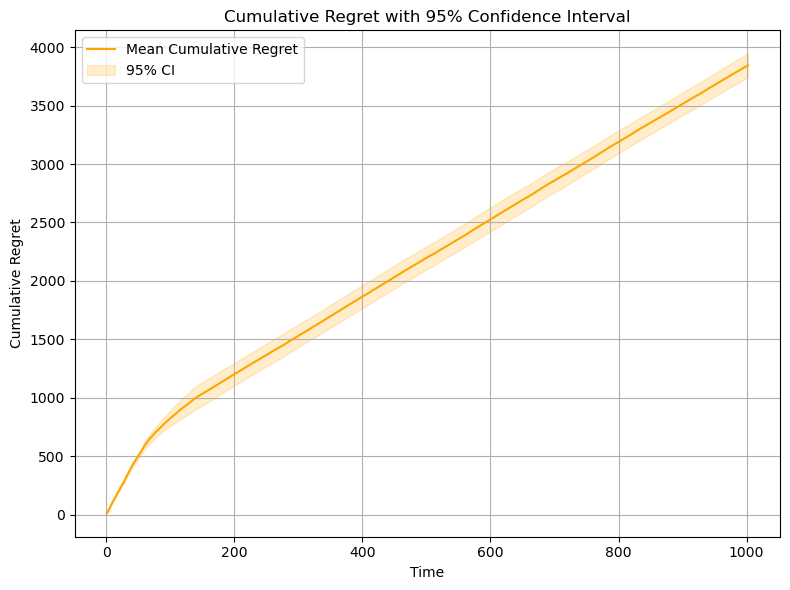

In [23]:
# Calculate the 95% confidence interval for the cumulative regret
lower_bound = cumulative_regret_mean - 1.96 * (cumulative_regret_std / np.sqrt(cumulative_regret_times.shape[0]))
upper_bound = cumulative_regret_mean + 1.96 * (cumulative_regret_std / np.sqrt(cumulative_regret_times.shape[0]))

# Plot the mean cumulative regret with confidence intervals
plt.figure(figsize=(8, 6))
time_steps = range(1, len(cumulative_regret_mean) + 1)

# Plot the mean line
plt.plot(time_steps, cumulative_regret_mean, label='Mean Cumulative Regret', color='orange')

# Fill the 95% confidence interval
plt.fill_between(time_steps, lower_bound, upper_bound, color='orange', alpha=0.2, label='95% CI')

# Add title, labels, and legend
plt.title('Cumulative Regret with 95% Confidence Interval')
plt.xlabel('Time')
plt.ylabel('Cumulative Regret')
plt.grid()
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

In [24]:
np.save('cumulative_regret_SA-lasso-bandit-d50-s5_10times.npy', cumulative_regret_times)
np.save('l_2_error_parameter_SA-lasso-bandit-d50-s5_10times.npy', l_2_error_parameter_times)